# SortStats-MLP — Notebook de Experimentos de ablacion


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import json
import time
import random
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '.')   
from sortstats_mlp import (
    SortStatsMLPClassifier, DATASET_CONFIGS,
    build_model, build_criterion, free_gpu_memory
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
Memoria total: 8.22 GB


## Configuración del experimento
**Modificar esta sección antes de cada corrida.**

In [365]:
# Opciones: 'santander' | 'diabetes' | 'forest_cover_small' |
#           'california' | 'adult' | 'electricity' | 'miniboone'
DATASET_NAME = 'electricity'

# Ruta al archivo CSV del dataset
DATA_PATH    = 'datasets/electricity.csv'

# Columna target y columna ID (si existe; None si no hay)
TARGET_COL   = 'target'
ID_COL       = None

# Para datasets multiclase: si las etiquetas empiezan en 1
# Cambiar a False si las etiquetas ya son 0-indexadas.
SUBTRACT_ONE_FROM_LABELS = False

# Variante de arquitectura 
#   None o [] - MLP estandar 
#   [0]       - SortStats en la entrada
#   [1]       - SortStats en la primera capa oculta
#   [2]       - SortStats en la segunda capa oculta
#   [0, 1]    - SortStats en entrada y primera capa oculta
#   [1, 2]    - SortStats en primera y segunda capa oculta
#   [0, 1, 2] - SortStats en todas las capas
APPLY_SORTSTATS_AT = [0]

# BRANCHES: ramas activas de la SortStats Layer.
#   'both'       - ambas ramas
#   'sort_only'  - solo ordenamiento
#   'stats_only' - solo estadisticos
BRANCHES = 'stats_only'

# Hiperparámetros
SEED          = 62             # semillas usadas: 42, 52, 62
EPOCHS        = 300            
ES_PATIENCE   = 30            
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
TEST_SIZE     = 0.2
STEEPNESS     = 5.0            # dureza de la relajacion del sort


EXPERIMENT_BLOCK = 'bloque2'
EXPERIMENT_NOTE  = 'Electricity - stats_only - [0] - seed 62'

RESULTS_DIR = Path('resultados')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Dataset      : {DATASET_NAME}')
print(f'SortStats at : {APPLY_SORTSTATS_AT}')
print(f'Branches     : {BRANCHES}')
print(f'Semilla      : {SEED}')
print(f'Bloque       : {EXPERIMENT_BLOCK}')

Dataset      : electricity
SortStats at : [0]
Branches     : stats_only
Semilla      : 62
Bloque       : bloque2


In [356]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'Semilla fijada: {SEED}')

Semilla fijada: 62


## Carga y preprocesamiento

In [357]:
df = pd.read_csv(DATA_PATH)
print(f'Shape original: {df.shape}')

drop_cols = [TARGET_COL] + ([ID_COL] if ID_COL else [])
X_np = df.drop(columns=drop_cols).values.astype(np.float32)
y_np = df[TARGET_COL].values.astype(np.int64)

if SUBTRACT_ONE_FROM_LABELS:
    y_np = y_np - 1
    print('Etiquetas convertidas a 0-index (se restó 1)')

NUM_CLASSES = int(y_np.max()) + 1
N_FEATURES  = X_np.shape[1]
CFG         = DATASET_CONFIGS[DATASET_NAME]

print(f'N_FEATURES  : {N_FEATURES}')
print(f'NUM_CLASSES : {NUM_CLASSES}')
print(f'Clases      : {np.bincount(y_np)}')
print(f'HIDDEN_DIMS : {CFG["hidden_dims"]}')
print(f'Batch size  : {CFG["batch_size"]}')

X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np, test_size=TEST_SIZE, stratify=y_np, random_state=SEED
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')

Shape original: (45312, 9)
N_FEATURES  : 8
NUM_CLASSES : 2
Clases      : [26075 19237]
HIDDEN_DIMS : [32, 16, 8]
Batch size  : 1024
Train: (36249, 8)  |  Val: (9063, 8)


In [358]:
BATCH_SIZE = CFG['batch_size']

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=(device == 'cuda'), num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=(device == 'cuda'), num_workers=0)

print(f'Batches por época — train: {len(train_loader)}  val: {len(val_loader)}')

Batches por época — train: 36  val: 9


## Modelo

In [366]:
free_gpu_memory()

model = build_model(
    dataset_name       = DATASET_NAME,
    n_features         = N_FEATURES,
    num_classes        = NUM_CLASSES,
    apply_sortstats_at = APPLY_SORTSTATS_AT,
    steepness          = STEEPNESS,
    branches           = BRANCHES,
).to(device)

criterion = build_criterion(num_classes=NUM_CLASSES, y_train=y_train)
if device == 'cuda' and hasattr(criterion, 'pos_weight') and criterion.pos_weight is not None:
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=criterion.pos_weight.to(device)
    )

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=4, factor=0.5
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros entrenables: {n_params:,}')
print(f'Hidden dims usados    : {CFG["hidden_dims"]}')
print(model)

GPU memoria reservada: 0.02 GB  asignada: 0.02 GB
Parametros entrenables: 1,201
Hidden dims usados    : [32, 16, 8]
SortStatsMLPClassifier(
  (sortstats_layers): ModuleDict(
    (0): SortStatsLayer()
  )
  (blocks): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=12, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=32, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=16, out_features=8, bias=True)
      (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
    )
  )
  (output_layer): Li

## Loop de entrenamiento

In [367]:
def prepare_targets(y_batch, num_classes):
    if num_classes == 2:
        return y_batch.float().unsqueeze(1)
    return y_batch.long()

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        y_b = prepare_targets(y_b, model.num_classes).to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_b)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        y_b = prepare_targets(y_b, model.num_classes).to(device)
        total_loss += criterion(model(X_b), y_b).item() * len(X_b)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_metrics(model, loader):
    model.eval()
    all_preds, all_probs, all_targets = [], [], []
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        all_preds.append(model.predict(X_b).cpu().numpy())
        all_probs.append(model.predict_proba(X_b).cpu().numpy())
        all_targets.append(y_b.numpy())
    preds   = np.concatenate(all_preds)
    probs   = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    acc = accuracy_score(targets, preds)
    f1  = f1_score(targets, preds, average='macro', zero_division=0)
    rec = recall_score(targets, preds, average='macro', zero_division=0)
    return acc, f1, rec, probs, targets

In [368]:
history = {k: [] for k in [
    'train_loss', 'val_loss', 'val_acc', 'val_f1', 'val_recall', 'epoch_time'
]}

best_val_f1    = -1.0
best_epoch     = 0
best_model_wts = None
no_improve     = 0

print(f'Entrenando hasta {EPOCHS} épocas (early stopping patience={ES_PATIENCE})...')
print(f'{"Epoch":>5}  {"tr_loss":>8}  {"vl_loss":>8}  {"vl_acc":>7}  '
      f'{"vl_f1":>7}  {"vl_rec":>7}  {"t(s)":>6}')

t_total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss = evaluate_loss(model, val_loader, criterion)
    vl_acc, vl_f1, vl_rec, _, _ = evaluate_metrics(model, val_loader)
    ep_time = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)
    history['val_recall'].append(vl_rec)
    history['epoch_time'].append(ep_time)

    scheduler.step(vl_loss)

    if vl_f1 > best_val_f1:
        best_val_f1    = vl_f1
        best_epoch     = epoch
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve     = 0
    else:
        no_improve += 1

    print(f'{epoch:>5}  {tr_loss:>8.4f}  {vl_loss:>8.4f}  {vl_acc:>7.4f}  '
          f'{vl_f1:>7.4f}  {vl_rec:>7.4f}  {ep_time:>6.1f}')

    if no_improve >= ES_PATIENCE:
        print(f'\nEarly stopping en época {epoch} '
              f'(mejor: época {best_epoch}, val_f1={best_val_f1:.4f})')
        break

t_total = time.time() - t_total_start
print(f'\nTiempo total: {t_total/60:.1f} min  |  Mejor época: {best_epoch}  |  '
      f'Mejor val_f1: {best_val_f1:.4f}')

model.load_state_dict(best_model_wts)
model.to(device)
print('Pesos del mejor modelo restaurados.')

Entrenando hasta 300 épocas (early stopping patience=30)...
Epoch   tr_loss   vl_loss   vl_acc    vl_f1   vl_rec    t(s)
    1    0.6977    0.6370   0.6471   0.6470   0.6589     0.4
    2    0.6310    0.5961   0.7307   0.7204   0.7181     0.3
    3    0.5954    0.5640   0.7612   0.7420   0.7368     0.4
    4    0.5643    0.5321   0.7693   0.7545   0.7493     0.3
    5    0.5428    0.5128   0.7707   0.7562   0.7510     0.5
    6    0.5286    0.4993   0.7744   0.7614   0.7564     0.3
    7    0.5184    0.4914   0.7749   0.7612   0.7560     0.3
    8    0.5127    0.4831   0.7774   0.7649   0.7599     0.3
    9    0.5077    0.4775   0.7793   0.7655   0.7600     0.3
   10    0.5033    0.4730   0.7844   0.7721   0.7668     0.3
   11    0.4999    0.4701   0.7852   0.7727   0.7673     0.3
   12    0.4978    0.4666   0.7854   0.7738   0.7688     0.4
   13    0.4969    0.4653   0.7880   0.7773   0.7725     0.3
   14    0.4973    0.4646   0.7876   0.7765   0.7715     0.3
   15    0.4937    0.4623

## Curvas de entrenamiento

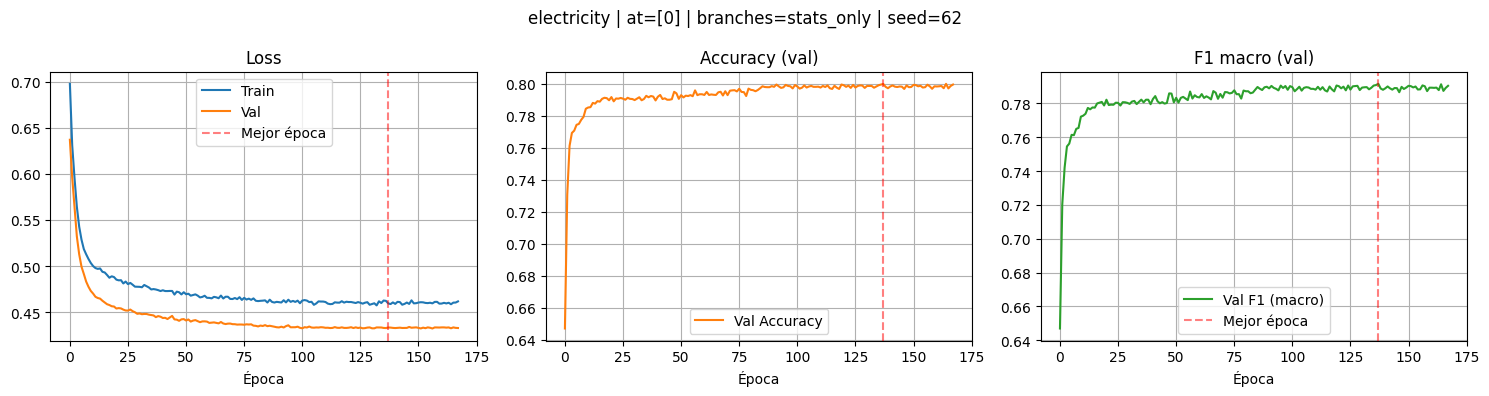

In [369]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label='Mejor época')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='tab:orange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy (val)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['val_f1'], label='Val F1 (macro)', color='tab:green')
axes[2].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label='Mejor época')
axes[2].set_title('F1 macro (val)')
axes[2].set_xlabel('Época')
axes[2].legend()
axes[2].grid(True)

plt.suptitle(f'{DATASET_NAME} | at={APPLY_SORTSTATS_AT} | branches={BRANCHES} | seed={SEED}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'curvas_{DATASET_NAME}_at{APPLY_SORTSTATS_AT}_{BRANCHES}_s{SEED}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Evaluación final

              precision    recall  f1-score   support

           0       0.80      0.87      0.83      5215
           1       0.80      0.71      0.75      3848

    accuracy                           0.80      9063
   macro avg       0.80      0.79      0.79      9063
weighted avg       0.80      0.80      0.80      9063

Accuracy : 0.7998
F1 macro : 0.7915
Recall   : 0.7876


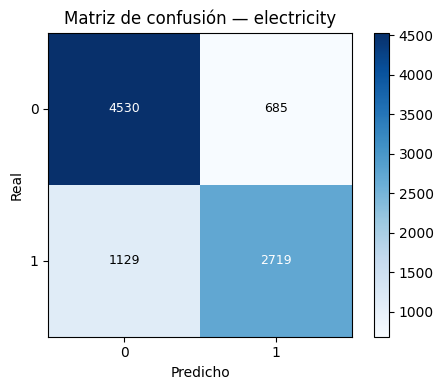

In [371]:
vl_acc, vl_f1, vl_rec, y_prob, y_true = evaluate_metrics(model, val_loader)
y_pred = np.concatenate([
    model.predict(X_b.to(device)).cpu().numpy()
    for X_b, _ in val_loader
])

print(classification_report(y_true, y_pred, zero_division=0))
print(f'Accuracy : {vl_acc:.4f}')
print(f'F1 macro : {vl_f1:.4f}')
print(f'Recall   : {vl_rec:.4f}')

cm     = confusion_matrix(y_true, y_pred)
n_cls  = cm.shape[0]
fig_sz = max(5, n_cls)
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz - 1))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión — {DATASET_NAME}')
ax.set_xticks(range(n_cls))
ax.set_yticks(range(n_cls))
fsize = 9 if n_cls <= 4 else 7
for (i, j), val in np.ndenumerate(cm):
    color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
    ax.text(j, i, f'{val}', ha='center', va='center', fontsize=fsize, color=color)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'cm_{DATASET_NAME}_at{APPLY_SORTSTATS_AT}_{BRANCHES}_s{SEED}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Registro de resultados

In [372]:
record = {
    'dataset'            : DATASET_NAME,
    'experiment_block'   : EXPERIMENT_BLOCK,
    'experiment_note'    : EXPERIMENT_NOTE,
    'apply_sortstats_at' : APPLY_SORTSTATS_AT,
    'branches'           : BRANCHES,
    'seed'               : SEED,
    'steepness'          : STEEPNESS,
    'hidden_dims'        : CFG['hidden_dims'],
    'batch_size'         : CFG['batch_size'],
    'lr'                 : LR,
    'weight_decay'       : WEIGHT_DECAY,
    'n_params'           : sum(p.numel() for p in model.parameters() if p.requires_grad),
    'best_epoch'         : best_epoch,
    'best_val_f1'        : round(best_val_f1, 6),
    'final_val_acc'      : round(vl_acc, 6),
    'final_val_f1'       : round(vl_f1, 6),
    'final_val_recall'   : round(vl_rec, 6),
    'total_time_min'     : round(t_total / 60, 2),
    'mean_epoch_time_s'  : round(float(np.mean(history['epoch_time'])), 2),
    'epochs_trained'     : len(history['train_loss']),
}

record_path = (RESULTS_DIR /
    f'record_{DATASET_NAME}_at{APPLY_SORTSTATS_AT}_{BRANCHES}_s{SEED}.json')
with open(record_path, 'w') as f:
    json.dump(record, f, indent=2)

print(f'Registro guardado: {record_path}')
print(json.dumps({k: v for k, v in record.items() if k != 'baselines'}, indent=2))

Registro guardado: resultados/record_electricity_at[0]_stats_only_s62.json
{
  "dataset": "electricity",
  "experiment_block": "bloque2",
  "experiment_note": "Electricity - stats_only - [0] - seed 62",
  "apply_sortstats_at": [
    0
  ],
  "branches": "stats_only",
  "seed": 62,
  "steepness": 5.0,
  "hidden_dims": [
    32,
    16,
    8
  ],
  "batch_size": 1024,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "n_params": 1201,
  "best_epoch": 138,
  "best_val_f1": 0.791521,
  "final_val_acc": 0.799846,
  "final_val_f1": 0.791521,
  "final_val_recall": 0.787624,
  "total_time_min": 0.94,
  "mean_epoch_time_s": 0.34,
  "epochs_trained": 168
}
